<table align="left">
  <td>
    <a href="https://colab.research.google.com/drive/1QaVU03VlON5QNvGSxNHiR5t2f-gWwAbh?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

**1. Import Libraries and Load Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


**Step 2: Data Preprocessing**

In [2]:
# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
data.head(3)

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8


In [3]:
# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
data['Temp'] = scaler.fit_transform(data['Temp'].values.reshape(-1, 1))

In [4]:
# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

In [7]:
# Prepare sequences

def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 30
X_train, y_train = create_sequences(train['Temp'].values, time_steps)
X_test, y_test   = create_sequences(test['Temp'].values, time_steps)


In [9]:
# Reshape to 3D for RNN/LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

**Step 3 Reusable Functions for Model Creation, Training, and Prediction**

In [10]:
def build_model(model_type='SimpleRNN', time_steps=30, units=50):

    model = Sequential()
    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units, activation='relu', input_shape=(time_steps, 1)))
    elif model_type == 'DeepRNN':
        model.add(SimpleRNN(units, activation='relu', return_sequences=True, input_shape=(time_steps, 1)))
        model.add(SimpleRNN(units, activation='relu'))
    elif model_type == 'LSTM':
        model.add(LSTM(units, activation='relu', return_sequences=True, input_shape=(time_steps, 1)))
        model.add(LSTM(units, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


**Function to Train Model**

In [13]:
def train_model(model, X_train, y_train, epochs=50):
    history = model.fit(X_train, y_train, epochs=epochs)
    return model, history


In [12]:
def evaluate_model(model, X_test, y_test, title='Model Evaluation'):

    # Make predictions on test set
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate MSE
    mse = mean_squared_error(y_test_actual, predictions)
    print(f'{title} - Mean Squared Error on Test Set: {mse}')

    # Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(data.index[-len(y_test):], y_test_actual, label='Actual Temperatures', color='blue')
    plt.plot(data.index[-len(y_test):], predictions, label=f'{title} Predictions', color='orange')
    plt.title(f'{title} - Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()
    return predictions, mse


In [11]:
def forecast_future(model, last_sequence, n_steps=30):

    predictions = []
    current_sequence = last_sequence

     # Update sequence with latest prediction
    for _ in range(n_steps):
        next_value = model.predict(current_sequence.reshape(1, time_steps, 1))
        predictions.append(next_value[0, 0])
        current_sequence = np.append(current_sequence[1:], next_value)

    # Inverse transform predictions
    future_predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return future_predictions


**Training, Evaluating, and Forecasting with Each Model**

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0520
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0107
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0102
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0092
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0091
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0086
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0089
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0094
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0088
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0085
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0085
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0089
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086
Epoch 16/50
91/91 ━━━━━━━━━

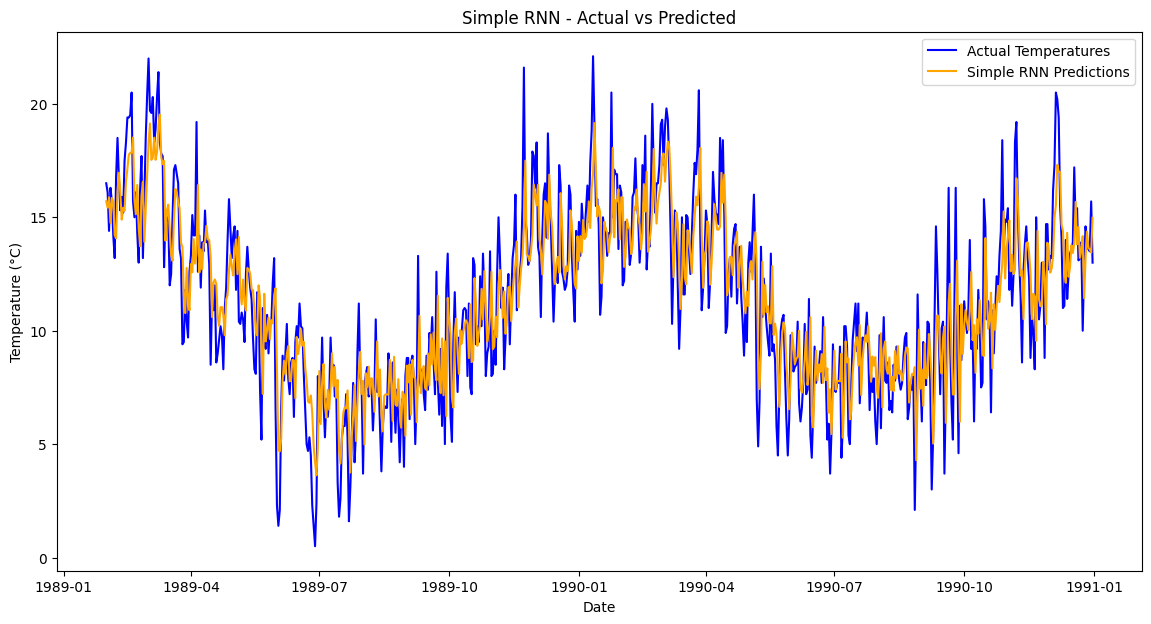

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [14]:
# Build, train, evaluate, and forecast with Simple RNN

simple_rnn = build_model(model_type='SimpleRNN')
simple_rnn, _ = train_model(simple_rnn, X_train, y_train)
simple_rnn_predictions, simple_rnn_mse = evaluate_model(simple_rnn, X_test, y_test, title='Simple RNN')
future_simple_rnn = forecast_future(simple_rnn, X_test[-1])

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0596
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0093
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0092
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0087
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0089
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0090
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0088
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0089
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0092
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0090
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0090
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0084
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0089
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0087
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0085
Epoch 16/50
91/

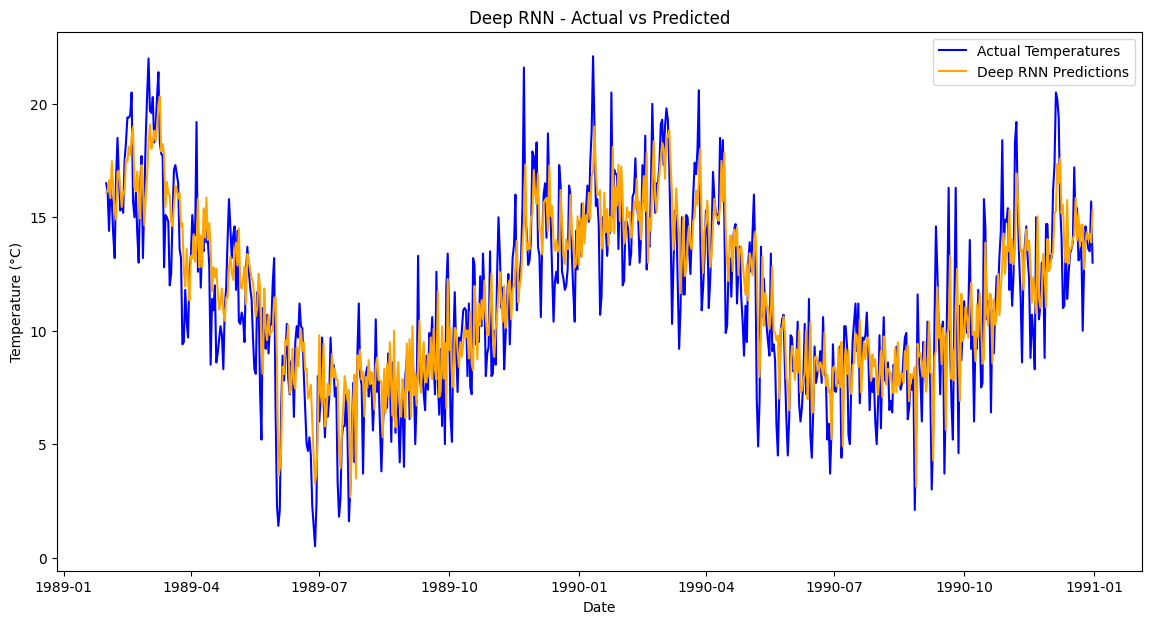

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

In [15]:
# Build, train, evaluate, and forecast with Deep RNN
deep_rnn = build_model(model_type='DeepRNN')
deep_rnn, _ = train_model(deep_rnn, X_train, y_train)
deep_rnn_predictions, deep_rnn_mse = evaluate_model(deep_rnn, X_test, y_test, title='Deep RNN')
future_deep_rnn = forecast_future(deep_rnn, X_test[-1])


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0837
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0120
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0124
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0122
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0120
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0116
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0113
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0119
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0106
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0115
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0107
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0109
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0105
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0106
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0096
Epoch 16/50
91/

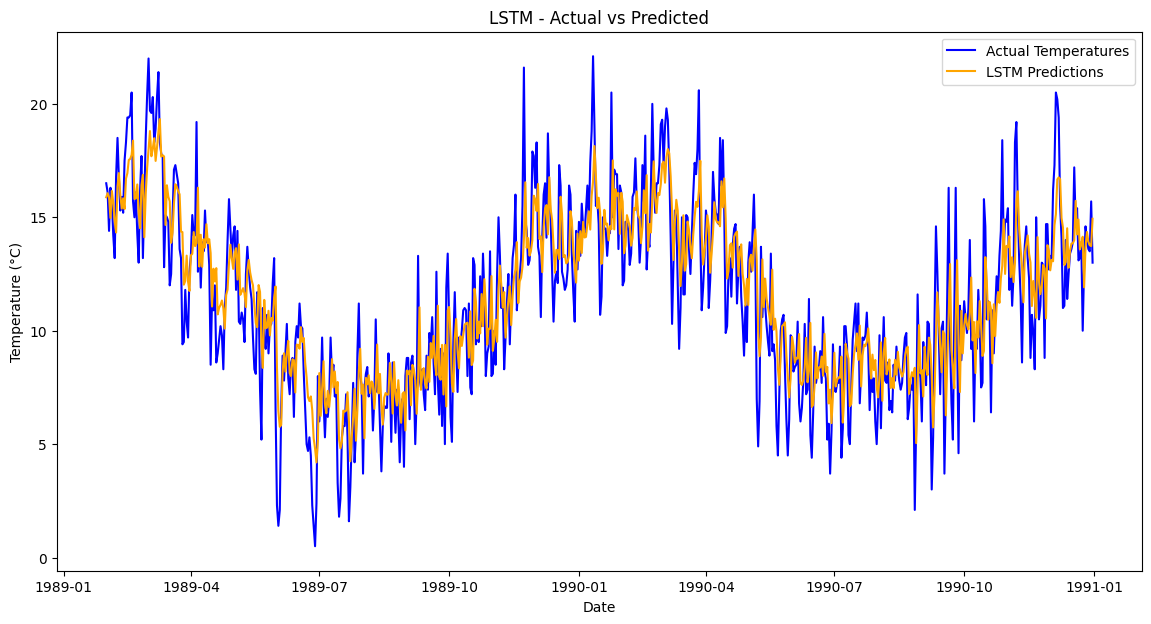

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

In [16]:
# Build, train, evaluate, and forecast with LSTM
lstm_model = build_model(model_type='LSTM')
lstm_model, _ = train_model(lstm_model, X_train, y_train)
lstm_predictions, lstm_mse = evaluate_model(lstm_model, X_test, y_test, title='LSTM')
future_lstm = forecast_future(lstm_model, X_test[-1])


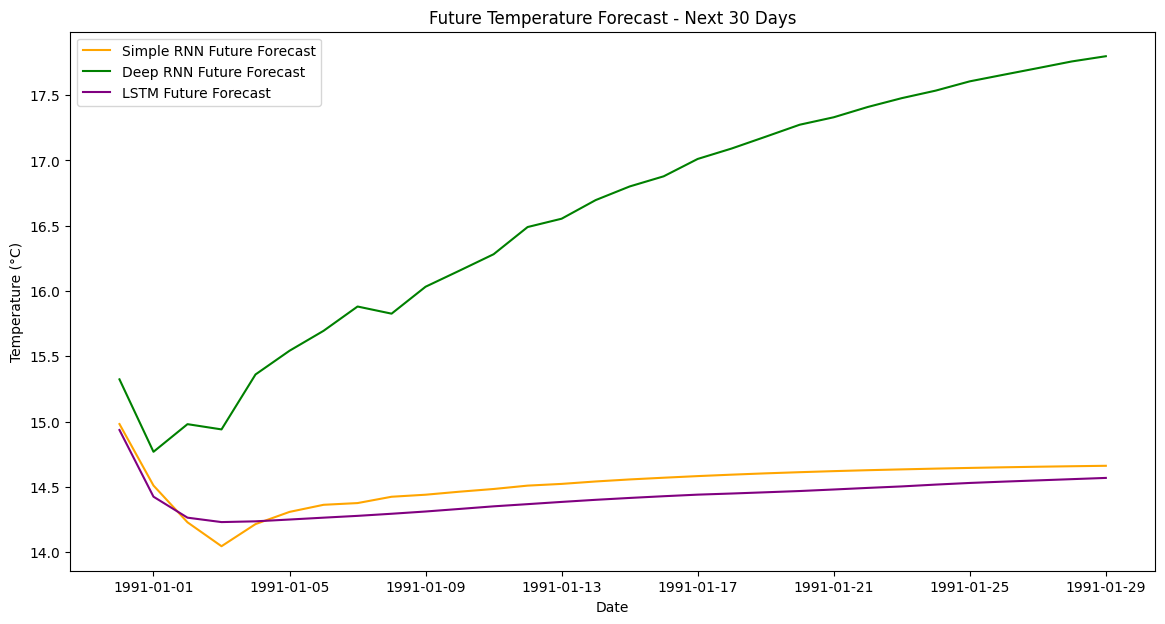

In [17]:
# Plot future predictions
plt.figure(figsize=(14, 7))
future_dates = pd.date_range(data.index[-1], periods=30, freq='D')

plt.plot(future_dates, future_simple_rnn, label='Simple RNN Future Forecast', color='orange')
plt.plot(future_dates, future_deep_rnn, label='Deep RNN Future Forecast', color='green')
plt.plot(future_dates, future_lstm, label='LSTM Future Forecast', color='purple')

plt.title('Future Temperature Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()
